<a href="https://colab.research.google.com/github/gamal-zayed/Quantized-Low-Rank-Adaptation-Parameter-Efficient-Fine-Tuning/blob/main/LoRA_DoRA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q trl peft bitsandbytes evaluate accelerate rouge_score bert_score

In [ ]:
# %% ==================== CELL 1: SETUP (run once) ====================
from google.colab import drive
drive.mount('/content/drive')

import os, gc, json, time, torch
import pandas as pd
import numpy as np
from collections import Counter
from transformers import (
    AutoConfig, AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, PeftModel
from trl import SFTTrainer, SFTConfig
from datasets import load_dataset
import evaluate
from tqdm import tqdm

MODEL_ID = "microsoft/Phi-3-mini-4k-instruct"

SEED = 42
TARGET_MODULES = ["qkv_proj", "o_proj", "gate_up_proj", "down_proj"]  #["gate_up_proj", "down_proj"]   # "MLP only" — the real fused
RANK = 16
                                                   # module names on Phi-3-mini.
DRIVE_ROOT = "/content/drive/MyDrive/exp_4_5_LoRA_DoRA"
os.makedirs(DRIVE_ROOT, exist_ok=True)

# ---- corrected fused-module parameter formula ----
PER_LAYER_COEF = {"qkv_proj": 7680, "o_proj": 6144, "gate_up_proj": 19456, "down_proj": 11264}
NUM_LAYERS = 32
def predicted_trainable_params(target_modules, r):
    return sum(PER_LAYER_COEF[m] for m in target_modules) * NUM_LAYERS * r

predicted = predicted_trainable_params(TARGET_MODULES, RANK)
print(f"Attention & MLP target_modules={TARGET_MODULES}, r={RANK}")
print(f"Predicted trainable params (fused-module formula): {predicted:,}")
print("Brief's own table claims ~33.74M for this row — trust "
      "print_trainable_parameters() over that figure; the brief's Section 4.4 "
      "table doesn't reconcile with its own Section 5 formula for any of its "
      "four rows, so this is very likely an error in the brief, not your setup.")
def audit_dtypes(model, label=""):
    all_dtypes = Counter(p.dtype for p in model.parameters())
    trainable_dtypes = Counter(p.dtype for p in model.parameters() if p.requires_grad)
    print(f"--- dtype audit {label} --- all: {dict(all_dtypes)} trainable: {dict(trainable_dtypes)}")
    return not any(p.requires_grad and p.dtype == torch.bfloat16 for p in model.parameters())

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=False)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

raw_dataset = load_dataset("keivalya/MedQuad-MedicalQnADataset", split="train")

def make_splits(seed, n_train=1500): #THINKING OF 500
    # n_train=1500 by default given time constraints seen earlier in this
    # project — bump back to 5000 if you have the hours to spare.
    shuffled = raw_dataset.shuffle(seed=seed)
    return shuffled.select(range(n_train)), shuffled.select(range(5000, 5500))

def formatting_prompts_func(examples):
    q_types = examples.get('qtype', [''] * len(examples[list(examples.keys())[0]]))
    questions = examples.get('Question', examples.get('question'))
    answers = examples.get('Answer', examples.get('answer'))
    texts = []
    for qt, q, a in zip(q_types, questions, answers):
        messages = [
            {"role": "system", "content": "You are a knowledgeable medical assistant. Answer the patient's question clearly and accurately."},
            {"role": "user", "content": f"Context: {qt}. Question: {q}"},
            {"role": "assistant", "content": a}
        ]
        texts.append(tokenizer.apply_chat_template(messages, tokenize=False))
    return {"text": texts}

QUALITATIVE_PROBES = [
    "What is the first-line treatment for hypertension in a diabetic patient?",
    "What are the symptoms of type 2 diabetes?",
    "What causes rheumatoid arthritis?",
    "How is pneumonia diagnosed?",
    "What is the recommended treatment for a urinary tract infection?",
]

print("Cell 1 setup complete.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Attention & MLP target_modules=['qkv_proj', 'o_proj', 'gate_up_proj', 'down_proj'], r=16
Predicted trainable params (fused-module formula): 22,806,528
Brief's own table claims ~33.74M for this row — trust print_trainable_parameters() over that figure; the brief's Section 4.4 table doesn't reconcile with its own Section 5 formula for any of its four rows, so this is very likely an error in the brief, not your setup.


config.json:   0%|          | 0.00/967 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/3.44k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.94M [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/599 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/233 [00:00<?, ?B/s]

medDataset_processed.csv:   0%|          | 0.00/22.5M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16407 [00:00<?, ? examples/s]

Cell 1 setup complete.


In [ ]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.device_count())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True
1
Tesla T4


In [ ]:
# %% ==================== CELL 2: TRAINING (LoRA + DoRA) ====================
# This is the long cell. Trains two configs: standard LoRA and DoRA
# (use_dora=True), both at r=8, MLP-only. Safe to re-run — already
# completed configs are skipped automatically.

def train_one_config(rank=RANK, seed=SEED, target_modules=TARGET_MODULES,
                      alpha_ratio=2, use_dora=False, n_train=1500):
    method_name = "dora" if use_dora else "lora"
    run_name = f"att_mlp_{method_name}_r{rank}_seed{seed}"
    adapter_dir = os.path.join(DRIVE_ROOT, run_name)
    meta_path = os.path.join(adapter_dir, "meta.json")

    if os.path.exists(meta_path):
        print(f"SKIPPING {run_name} — already completed, found on Drive.")
        with open(meta_path) as f:
            return json.load(f)

    print(f"\n{'='*60}\nTRAINING: {method_name.upper()}  rank={rank}  seed={seed}\n{'='*60}")

    from accelerate.state import AcceleratorState, PartialState
    AcceleratorState._reset_state()
    PartialState._reset_state()

    train_dataset, val_dataset = make_splits(seed, n_train=n_train)
    train_dataset = train_dataset.map(formatting_prompts_func, batched=True)
    val_dataset = val_dataset.map(formatting_prompts_func, batched=True)

    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True, bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float16, # Gradient Checkpointing?
        bnb_4bit_use_double_quant=True,  # I need to make sure Batch Size = 4
    )

    config = AutoConfig.from_pretrained(MODEL_ID)
    config._attn_implementation = "sdpa"   # revert to "eager" here if this throws
                                            # a rotary-embedding-related error

    base_model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID, config=config, quantization_config=bnb_config,
        device_map={"": 0}, trust_remote_code=False, torch_dtype=torch.float16,
    )
    base_model.config.use_cache = False
    base_model = prepare_model_for_kbit_training(base_model)

    peft_kwargs = dict(
        r=rank, lora_alpha=rank * alpha_ratio, target_modules=target_modules,
        lora_dropout=0.05, bias="none", task_type="CAUSAL_LM",
    )
    if use_dora:
        peft_kwargs["use_dora"] = True
        # Known risk: DoRA + 4-bit quantized base has had compatibility issues
        # in some peft versions. If this raises an error mentioning
        # quantization/DoRA incompatibility, try: !pip install -U peft
    peft_config = LoraConfig(**peft_kwargs)

    try:
        model = get_peft_model(base_model, peft_config)
    except Exception as e:
        print(f"get_peft_model failed for use_dora={use_dora}: {e}")
        print("If this mentions quantization/DoRA incompatibility, upgrade peft "
              "(!pip install -U peft) and restart the runtime, then retry.")
        raise

    ok = audit_dtypes(model, label=f"({method_name}, r={rank}, seed={seed})")
    if not ok:
        for p in model.parameters():
            if p.requires_grad and p.dtype == torch.bfloat16:
                p.data = p.data.to(torch.float16)

    trainable_actual = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Predicted: {predicted:,} | Actual: {trainable_actual:,}")

    out_dir = f"{DRIVE_ROOT}/{run_name}"
    training_config = SFTConfig(
        output_dir=out_dir,
        dataset_text_field="text",
        max_length=384,# was 512: modest speedup, medical answers rarely need more
        packing=False,
        per_device_train_batch_size=8,
        gradient_accumulation_steps=1,   # if this OOMs: batch_size=4, accum=2
        learning_rate=2e-4,
        num_train_epochs=1, #WAS 3,
        logging_steps=10,
        eval_strategy="epoch",
        save_strategy="steps",
        save_steps=50,
        fp16=False, bf16=False,
        optim="paged_adamw_8bit",
        seed=seed,
        report_to=[],
    )
    training_config._n_gpu = 1

    trainer = SFTTrainer(
        model=model, train_dataset=train_dataset, eval_dataset=val_dataset,
        processing_class=tokenizer, args=training_config,
    )

    resume = os.path.isdir(out_dir) and any(d.startswith("checkpoint-") for d in os.listdir(out_dir))
    if resume:
        print(f"Found existing checkpoint in {out_dir} — resuming.")

    t0 = time.time()
    trainer.train(resume_from_checkpoint=resume)
    wall_time = time.time() - t0
    val_loss = trainer.evaluate()["eval_loss"]

    model.save_pretrained(adapter_dir)
    tokenizer.save_pretrained(adapter_dir)

    meta = {
        "strategy": "attention_mlp", "method": method_name,
        "rank": rank, "seed": seed, "target_modules": target_modules,
        "use_dora": use_dora,
        "trainable_params_predicted": predicted,
        "trainable_params_actual": trainable_actual,
        "wall_time_sec": wall_time, "val_loss": val_loss,
        "adapter_dir": adapter_dir,
    }
    with open(meta_path, "w") as f:
        json.dump(meta, f, indent=2)

    del trainer, model, base_model
    gc.collect(); torch.cuda.empty_cache()
    return meta


# Train both configs. Safe to re-run this cell if it crashes partway —
# completed configs are skipped, and in-progress ones resume from their
# last local checkpoint (unless the whole runtime disconnected, in which
# case that one config restarts, same as we saw in Experiment 4.3).
lora_meta = train_one_config(use_dora=False)
print("LoRA done:", lora_meta)

RUN_DORA = True  # flip to True only if you have time left after checking Cell 3 results
print(pd.DataFrame([lora_meta])[
    ["method", "rank", "trainable_params_actual", "wall_time_sec", "val_loss"]])

if RUN_DORA:
    dora_meta = train_one_config(use_dora=True)
    print(pd.DataFrame([dora_meta])[["method","rank","trainable_params_actual","wall_time_sec","val_loss"]])
    print("\nTraining complete for both LoRA and DoRA configs.")
else:
    print("\nTraining complete for LoRA config.")

SKIPPING att_mlp_lora_r16_seed42 — already completed, found on Drive.
LoRA done: {'strategy': 'attention_mlp', 'method': 'lora', 'rank': 16, 'seed': 42, 'target_modules': ['qkv_proj', 'o_proj', 'gate_up_proj', 'down_proj'], 'use_dora': False, 'trainable_params_predicted': 22806528, 'trainable_params_actual': 25165824, 'wall_time_sec': 1894.9710066318512, 'val_loss': 0.8204253911972046, 'adapter_dir': '/content/drive/MyDrive/exp_4_5_LoRA_DoRA/att_mlp_lora_r16_seed42'}
  method  rank  trainable_params_actual  wall_time_sec  val_loss
0   lora    16                 25165824    1894.971007  0.820425
SKIPPING att_mlp_dora_r16_seed42 — already completed, found on Drive.
  method  rank  trainable_params_actual  wall_time_sec  val_loss
0   dora    16                 26181632    4685.192875  0.818379

Training complete for both LoRA and DoRA configs.


In [ ]:
# %% ==================== CELL 3: EVAL (run any time after Cell 2) ====================
# Loads the base model once, evaluates both saved adapters (LoRA + DoRA)
# with ROUGE-L, BERTScore, and the qualitative probe questions.

from bert_score import utils as bs_utils  # noqa: ensure import path exists

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True, bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16, bnb_4bit_use_double_quant=True,
)
config = AutoConfig.from_pretrained(MODEL_ID)
config._attn_implementation = "sdpa"

print("Loading base model once for all eval runs...")
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, config=config, quantization_config=bnb_config,
    device_map={"": 0}, trust_remote_code=False, torch_dtype=torch.float16,
)
base_model.config.use_cache = True   # needed for generate()

rouge = evaluate.load("rouge")

# Fix for OverflowError: int too big to convert (DeBERTa tokenizer has no
# model_max_length set, defaults to an unbounded sentinel that newer
# `tokenizers` versions overflow on). Intercept AutoTokenizer.from_pretrained
# globally so any tokenizer loaded anywhere — including inside bert_score's
# internals — gets clamped to a sane value.
from transformers import AutoTokenizer as _AutoTokenizer
_orig_from_pretrained = _AutoTokenizer.from_pretrained.__func__
def _clamped_from_pretrained(cls, *args, **kwargs):
    tok = _orig_from_pretrained(cls, *args, **kwargs)
    if getattr(tok, "model_max_length", 0) > 100000:
        print(f"Clamping absurd model_max_length -> 512 for tokenizer from "
              f"{args[0] if args else kwargs.get('pretrained_model_name_or_path')}")
        tok.model_max_length = 512
    return tok
_AutoTokenizer.from_pretrained = classmethod(_clamped_from_pretrained)

bertscore = evaluate.load("bertscore")

def make_val_split(seed):
    shuffled = raw_dataset.shuffle(seed=seed)
    return shuffled.select(range(5000, 5500))

def evaluate_adapter(adapter_dir, n_eval=10):  #EDITTED n_eval WAS 20
    with open(os.path.join(adapter_dir, "meta.json")) as f:
        meta = json.load(f)

    print(f"\nEvaluating {adapter_dir}  ({meta['method']}, r={meta['rank']})")
    model = PeftModel.from_pretrained(base_model, adapter_dir)
    model.eval()

    val_dataset = make_val_split(meta["seed"]).select(range(n_eval))
    references, predictions = [], []
    for sample in tqdm(val_dataset, desc="generating"):
        ref = sample.get('Answer', sample.get('answer', ''))
        references.append(ref)
        qt = sample.get('qtype', '')
        q = sample.get('Question', sample.get('question', ''))
        messages = [
            {"role": "system", "content": "You are a knowledgeable medical assistant. Answer the patient's question clearly and accurately."},
            {"role": "user", "content": f"Context: {qt}. Question: {q}"},
        ]
        prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = tokenizer(prompt, return_tensors="pt").to("cuda:0")
        with torch.no_grad():
            out = model.generate(**inputs, max_new_tokens=150, do_sample=False)
        decoded = tokenizer.decode(out[0][inputs.input_ids.shape[1]:], skip_special_tokens=True)
        predictions.append(decoded.strip())

    rouge_res = rouge.compute(predictions=predictions, references=references)
    bert_res = bertscore.compute(predictions=predictions, references=references,
                                  model_type="microsoft/deberta-xlarge-mnli")

    # qualitative probes for the write-up
    qualitative = []
    for q in QUALITATIVE_PROBES:
        messages = [
            {"role": "system", "content": "You are a knowledgeable medical assistant. Answer the patient's question clearly and accurately."},
            {"role": "user", "content": q},
        ]
        prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = tokenizer(prompt, return_tensors="pt").to("cuda:0")
        with torch.no_grad():
            out = model.generate(**inputs, max_new_tokens=200, do_sample=False)
        decoded = tokenizer.decode(out[0][inputs.input_ids.shape[1]:], skip_special_tokens=True)
        qualitative.append({"question": q, "answer": decoded.strip()})

    with open(os.path.join(adapter_dir, "qualitative.json"), "w") as f:
        json.dump(qualitative, f, indent=2)

    model = model.unload()

    meta["rougeL"] = rouge_res["rougeL"]
    meta["bertscore_f1"] = float(np.mean(bert_res["f1"]))
    return meta


# adapter_dirs = sorted(
#     os.path.join(DRIVE_ROOT, d) for d in os.listdir(DRIVE_ROOT)
#     if os.path.isdir(os.path.join(DRIVE_ROOT, d))
# )
adapter_dirs = [
    os.path.join(DRIVE_ROOT, "att_mlp_lora_r16_seed42"),
    os.path.join(DRIVE_ROOT, "att_mlp_dora_r16_seed42"),
]
results = [evaluate_adapter(d) for d in adapter_dirs]

df = pd.DataFrame(results)
df.to_csv(os.path.join(DRIVE_ROOT, "exp_4_4_lora_vs_dora_results.csv"), index=False)
print(df[["method", "rank", "trainable_params_actual", "wall_time_sec",
          "val_loss", "rougeL", "bertscore_f1"]])
print(f"\nSaved to {DRIVE_ROOT}/exp_4_4_lora_vs_dora_results.csv")
print("Compare val_loss/rougeL/bertscore_f1 between the lora and dora rows — "
      "that comparison IS the exceptional-tier deliverable per Section 12.3. "
      "Check qualitative.json in each adapter's folder for example answers "
      "to quote in your write-up.")

Loading base model once for all eval runs...


model.safetensors.index.json:   0%|          | 0.00/16.5k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


...

Loading weights:   0%|          | 0/772 [00:00<?, ?it/s]

[transformers] DebertaModel LOAD REPORT from: microsoft/deberta-xlarge-mnli
Key                 | Status     |  | 
--------------------+------------+--+-
classifier.bias     | UNEXPECTED |  | 
pooler.dense.bias   | UNEXPECTED |  | 
classifier.weight   | UNEXPECTED |  | 
pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Evaluating /content/drive/MyDrive/exp_4_5_LoRA_DoRA/att_mlp_dora_r16_seed42  (dora, r=16)



generating: 100%|██████████| 10/10 [16:52<00:00, 101.27s/it]


  method  rank  trainable_params_actual  wall_time_sec  val_loss    rougeL  \
0   lora    16                 25165824    1894.971007  0.820425  0.317331   
1   dora    16                 26181632    4685.192875  0.818379  0.313955   

   bertscore_f1  
0      0.666390  
1      0.673528  

Saved to /content/drive/MyDrive/exp_4_5_LoRA_DoRA/exp_4_4_lora_vs_dora_results.csv
Compare val_loss/rougeL/bertscore_f1 between the lora and dora rows — that comparison IS the exceptional-tier deliverable per Section 12.3. Check qualitative.json in each adapter's folder for example answers to quote in your write-up.


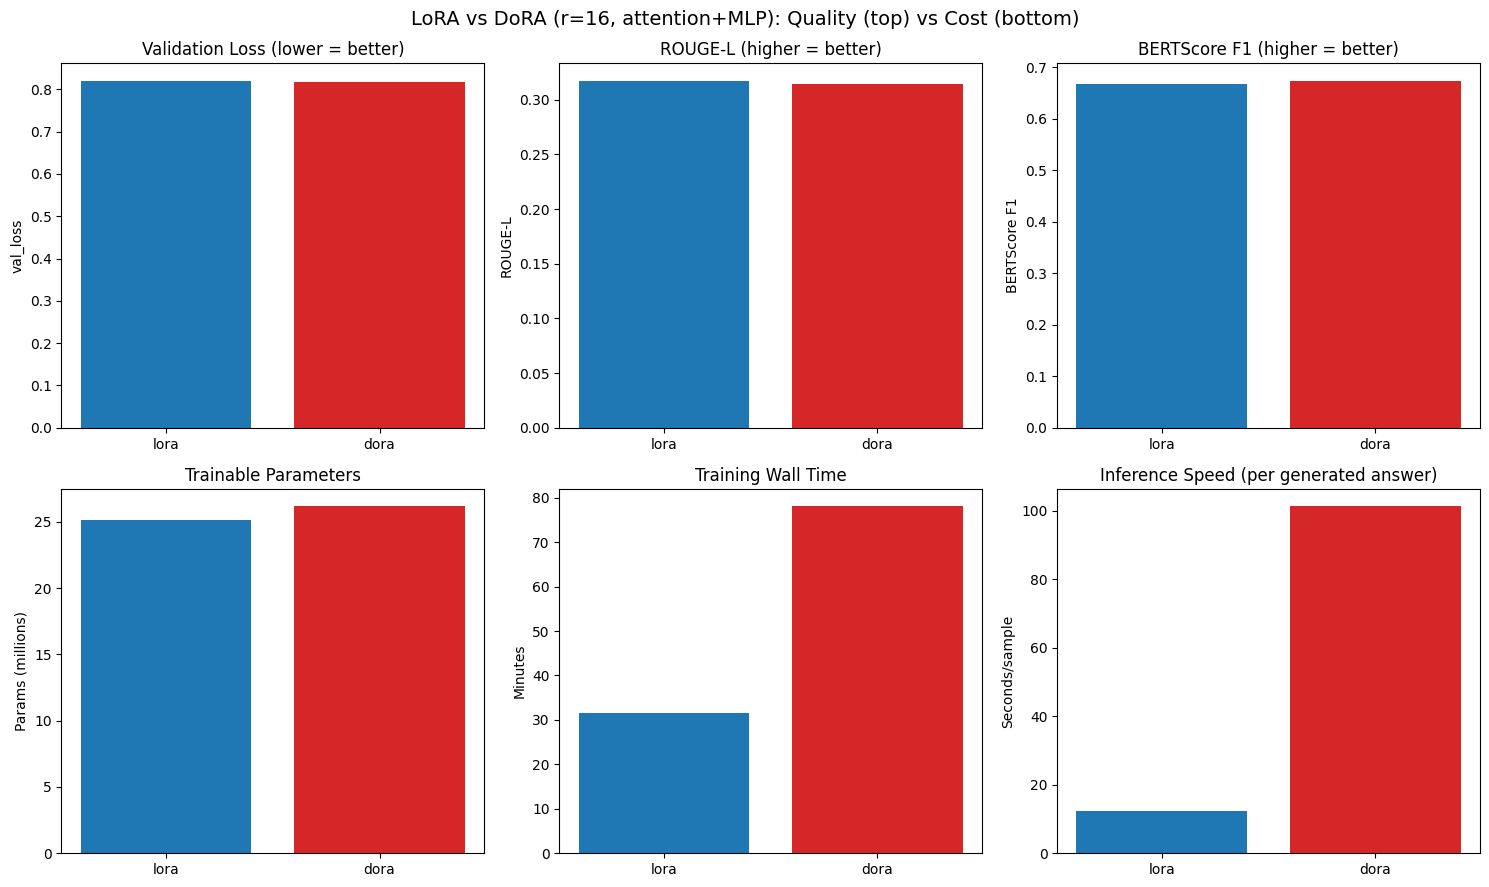

Saved /content/drive/MyDrive/exp_4_5_LoRA_DoRA/exp_4_5_lora_vs_dora_comparison.png

DoRA vs LoRA -- percent change (positive = DoRA higher/slower):
  val_loss (lower better)             -0.2%
  rougeL (higher better)              -1.1%
  bertscore_f1 (higher better)        +1.1%
  trainable_params                    +4.0%
  training_time                     +147.2%
  inference_time_per_sample         +730.8%


In [ ]:
# %% ==================== CELL 4: LoRA vs DoRA -- COMPARISON VISUALIZATIONS ====================
# Run any time after Cell 3. Builds a 2x3 comparison: top row = quality
# metrics, bottom row = cost metrics (this is the real story in your data --
# quality is nearly a wash, but cost is not).

import matplotlib.pyplot as plt

df_compare = pd.read_csv(os.path.join(DRIVE_ROOT, "exp_4_4_lora_vs_dora_results.csv"))
df_compare = df_compare.set_index("method").loc[["lora", "dora"]].reset_index()

# Per-sample inference time, read off the tqdm generation rate in your Cell 3
# output ("12.19s/it" for LoRA, "101.27s/it" average for DoRA). Not saved to
# meta.json automatically -- if you rerun eval, capture this programmatically
# instead (wrap the generation loop with time.time() and divide by n_eval).
inference_sec_per_sample = {"lora": 12.19, "dora": 101.27}
df_compare["inference_sec_per_sample"] = df_compare["method"].map(inference_sec_per_sample)
df_compare["wall_time_min"] = df_compare["wall_time_sec"] / 60

colors = {"lora": "tab:blue", "dora": "tab:red"}
bar_colors = [colors[m] for m in df_compare["method"]]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# ---- Top row: quality metrics ----
axes[0, 0].bar(df_compare["method"], df_compare["val_loss"], color=bar_colors)
axes[0, 0].set_title("Validation Loss (lower = better)")
axes[0, 0].set_ylabel("val_loss")

axes[0, 1].bar(df_compare["method"], df_compare["rougeL"], color=bar_colors)
axes[0, 1].set_title("ROUGE-L (higher = better)")
axes[0, 1].set_ylabel("ROUGE-L")

axes[0, 2].bar(df_compare["method"], df_compare["bertscore_f1"], color=bar_colors)
axes[0, 2].set_title("BERTScore F1 (higher = better)")
axes[0, 2].set_ylabel("BERTScore F1")

# ---- Bottom row: cost metrics ----
axes[1, 0].bar(df_compare["method"], df_compare["trainable_params_actual"] / 1e6, color=bar_colors)
axes[1, 0].set_title("Trainable Parameters")
axes[1, 0].set_ylabel("Params (millions)")

axes[1, 1].bar(df_compare["method"], df_compare["wall_time_min"], color=bar_colors)
axes[1, 1].set_title("Training Wall Time")
axes[1, 1].set_ylabel("Minutes")

axes[1, 2].bar(df_compare["method"], df_compare["inference_sec_per_sample"], color=bar_colors)
axes[1, 2].set_title("Inference Speed (per generated answer)")
axes[1, 2].set_ylabel("Seconds/sample")

for ax in axes.flat:
    ax.set_xlabel("")

plt.suptitle("LoRA vs DoRA (r=16, attention+MLP): Quality (top) vs Cost (bottom)", fontsize=14)
plt.tight_layout()
out_path = os.path.join(DRIVE_ROOT, "exp_4_5_lora_vs_dora_comparison.png")
plt.savefig(out_path, dpi=150)
plt.show()
print(f"Saved {out_path}")

# ---- Percent-difference summary table (DoRA relative to LoRA) ----
pct_diff = {
    "val_loss (lower better)": (df_compare.loc[1,"val_loss"] / df_compare.loc[0,"val_loss"] - 1) * 100,
    "rougeL (higher better)": (df_compare.loc[1,"rougeL"] / df_compare.loc[0,"rougeL"] - 1) * 100,
    "bertscore_f1 (higher better)": (df_compare.loc[1,"bertscore_f1"] / df_compare.loc[0,"bertscore_f1"] - 1) * 100,
    "trainable_params": (df_compare.loc[1,"trainable_params_actual"] / df_compare.loc[0,"trainable_params_actual"] - 1) * 100,
    "training_time": (df_compare.loc[1,"wall_time_sec"] / df_compare.loc[0,"wall_time_sec"] - 1) * 100,
    "inference_time_per_sample": (df_compare.loc[1,"inference_sec_per_sample"] / df_compare.loc[0,"inference_sec_per_sample"] - 1) * 100,
}
print("\nDoRA vs LoRA -- percent change (positive = DoRA higher/slower):")
for k, v in pct_diff.items():
    print(f"  {k:32s} {v:+7.1f}%")